# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.preprocessing import StandardScaler

# Konfigurasi visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Type your code here
file_path = 'football_player_stats.csv'

try:
    # Menggunakan sep=';' dan encoding 'latin-1' sesuai karakteristik data sepak bola Eropa
    df_raw = pd.read_csv(file_path, encoding='latin-1', sep=';')
    print("✓ Dataset berhasil dimuat!")

    # Menampilkan dimensi data
    print(f"Dimensi Dataset: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom\n")

    # Menampilkan 5 baris pertama untuk inspeksi awal
    display(df_raw.head())
except FileNotFoundError:
    print(f"❌ File '{file_path}' tidak ditemukan. Pastikan dataset sudah diunggah ke Colab.")

✓ Dataset berhasil dimuat!
Dimensi Dataset: 2921 baris, 143 kolom



,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Max Aarons,ENG,DF,Norwich City,Premier League,22.0,2000,34,32,...,0.03,1.41,1.16,0.0,0.06,0.03,5.53,0.47,1.59,22.7
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34.0,1987,34,34,...,0.00,0.06,1.39,0.0,0.03,0.00,6.77,2.02,1.36,59.8
2,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,22.0,2000,31,29,...,0.00,0.36,1.24,0.0,0.00,0.00,8.76,0.88,0.88,50.0
3,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29.0,1993,34,34,...,0.03,0.79,2.23,0.0,0.00,0.00,8.87,0.43,0.43,50.0
4,5,Charles Abi,FRA,FW,Saint-Étienne,Ligue 1,22.0,2000,1,1,...,0.00,2.00,0.00,0.0,0.00,0.00,4.00,2.00,0.00,100.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Columns: 143 entries, Rk to AerWon%
dtypes: float64(133), int64(5), object(5)
memory usage: 3.2+ MB

=== Statistik Deskriptif ===


,Rk,Age,Born,MP,Starts,Min,90s,Goals,Shots,SoT,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
count,2921.000000,2920.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,...,2921.000000,2921.000000,2921.000000,2921.00000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000,2921.000000
mean,1461.000000,26.092123,1994.725094,18.800068,13.749743,1234.756248,13.719069,0.111274,1.220431,0.391462,...,0.195029,1.063708,1.026689,0.01519,0.013050,0.003451,7.410294,1.664286,1.858305,40.485861
std,843.364393,4.641746,37.210426,11.619882,11.393763,977.941288,10.865255,0.233688,1.511266,0.784754,...,0.509935,1.341177,1.028466,0.21167,0.052864,0.020306,3.650554,1.938046,2.245096,24.297290
min,1.000000,16.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,731.000000,23.000000,1992.000000,8.000000,3.000000,307.000000,3.400000,0.000000,0.280000,0.000000,...,0.000000,0.000000,0.430000,0.00000,0.000000,0.000000,5.070000,0.520000,0.840000,26.200000
50%,1461.000000,26.000000,1996.000000,20.000000,12.000000,1102.000000,12.200000,0.000000,0.820000,0.190000,...,0.000000,0.590000,0.920000,0.00000,0.000000,0.000000,7.380000,1.230000,1.390000,43.500000
75%,2191.000000,29.000000,1999.000000,29.000000,23.000000,2025.000000,22.500000,0.150000,1.830000,0.560000,...,0.200000,1.700000,1.410000,0.00000,0.000000,0.000000,9.380000,2.270000,2.210000,57.100000
max,2921.000000,41.000000,2006.000000,38.000000,38.000000,3420.000000,38.000000,5.000000,20.000000,20.000000,...,10.000000,15.000000,10.000000,10.00000,1.430000,0.500000,40.000000,30.000000,40.000000,100.000000



=== Persentase Missing Values ===
Nation    0.034235
Age       0.034235
dtype: float64


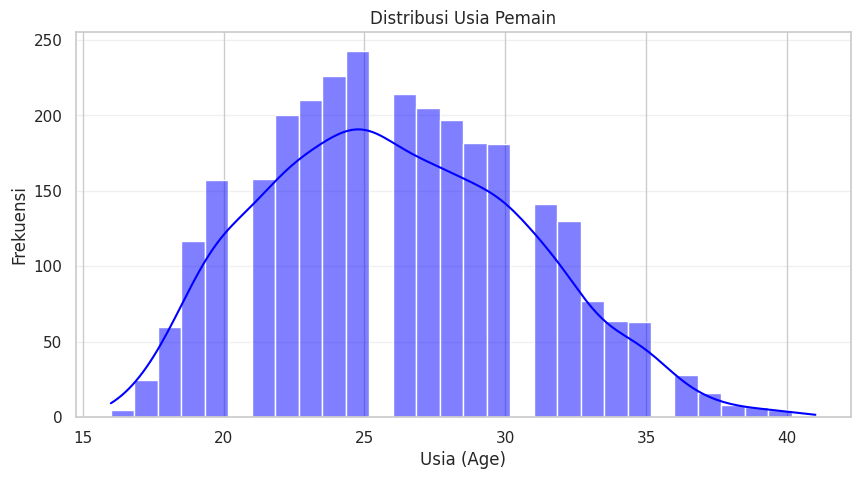

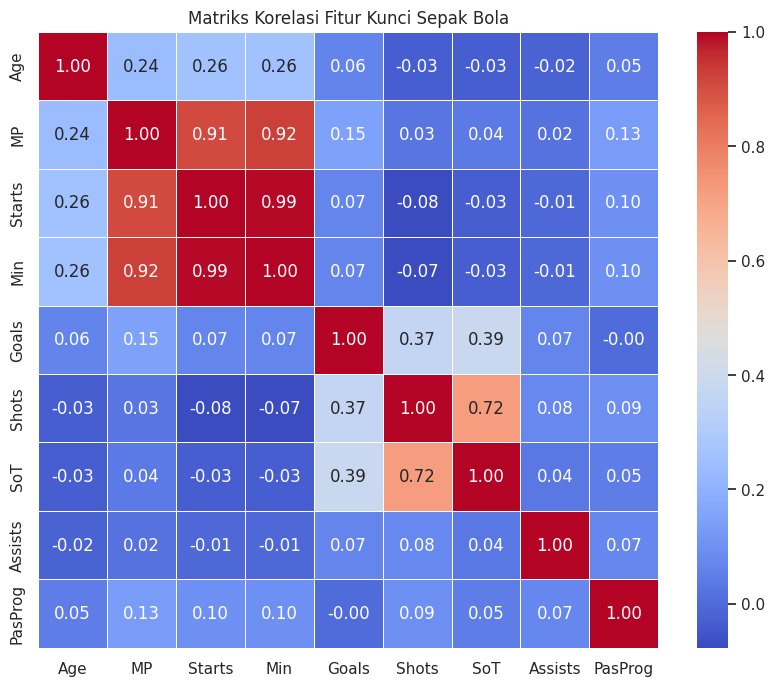

In [3]:
# Type your code here
# 1. Informasi umum struktur data dan tipe data
print("=== Informasi Dataset ===")
df_raw.info()

# 2. Statistik deskriptif untuk fitur numerik
print("\n=== Statistik Deskriptif ===")
display(df_raw.describe())

# 3. Mengecek distribusi nilai kosong (Missing Values)
print("\n=== Persentase Missing Values ===")
missing_data = df_raw.isnull().sum() / len(df_raw) * 100
print(missing_data[missing_data > 0].sort_values(ascending=False))

# 4. Visualisasi Distribusi Atribut Utama (Usia Pemain)
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['Age'], bins=30, kde=True, color='blue')
plt.title('Distribusi Usia Pemain')
plt.xlabel('Usia (Age)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 5. Visualisasi Korelasi antar fitur numerik (Fokus pada fitur pencetak gol/kontribusi)
# Memilih beberapa fitur kunci dari 143 kolom agar heatmap mudah dibaca
fitur_kunci = ['Age', 'MP', 'Starts', 'Min', 'Goals', 'Shots', 'SoT', 'Assists', 'PasProg']

plt.figure(figsize=(10, 8))
correlation_matrix = df_raw[fitur_kunci].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Kunci Sepak Bola')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# Type your code here
# 1. Menyalin data agar dataset raw tetap utuh
df_clean = df_raw.copy()

# Standardisasi nama kolom menjadi huruf kecil semua (mencegah isu kapitalisasi)
df_clean.columns = df_clean.columns.str.lower()

# 2. Menghapus Data Duplikat & Missing Values
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()

# Menghapus baris yang kosong pada kolom fitur krusial
required_cols = ['age', 'goals', 'shots']
df_clean = df_clean.dropna(subset=required_cols)
print(f"Sisa baris setelah pembersihan duplikat & missing values: {df_clean.shape[0]}")

# 3. Deteksi dan Penanganan Outlier menggunakan metode Vectorized IQR
columns_to_filter = ['age', 'goals', 'shots']

for col in columns_to_filter:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        # Efisiensi: Filtering langsung pada DataFrame tanpa perulangan baris (iterrows)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Dimensi data setelah pembersihan outlier: {df_clean.shape}")

# 4. Encoding Data Kategorikal (One-Hot Encoding untuk kolom Posisi/pos)
if 'pos' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['pos'], drop_first=True)

# 5. Standarisasi Fitur Numerik
scaler = StandardScaler()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

# Kecualikan ID unik (rk), tahun lahir (born), dan hasil dari dummy encoding (pos_)
exclude_cols = ['rk', 'born']
cols_to_scale = [c for c in numeric_cols if c not in exclude_cols and not c.startswith('pos_')]

# Menerapkan standardisasi hanya pada kolom yang memenuhi syarat
if len(cols_to_scale) > 0:
    df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# Menampilkan hasil akhir preprocessing
print("\n=== Data Siap Latih (5 Baris Pertama) ===")
display(df_clean.head())

print(f"Dimensi akhir data siap latih setelah encoding: {df_clean.shape}")

Sisa baris setelah pembersihan duplikat & missing values: 2920
Dimensi data setelah pembersihan outlier: (2593, 143)

=== Data Siap Latih (5 Baris Pertama) ===


,rk,player,nation,squad,comp,age,born,mp,starts,min,...,pos_DFFW,pos_DFMF,pos_FW,pos_FWDF,pos_FWMF,pos_GK,pos_GKMF,pos_MF,pos_MFDF,pos_MFFW
0,1,Max Aarons,ENG,Norwich City,Premier League,-0.881471,2000,1.309820,1.583469,1.662277,...,False,False,False,False,False,False,False,False,False,False
1,2,Yunis Abdelhamid,MAR,Reims,Ligue 1,1.757853,1987,1.309820,1.759675,1.766745,...,False,False,False,False,False,False,False,False,False,False
2,3,Salis Abdul Samed,GHA,Clermont Foot,Ligue 1,-0.881471,2000,1.050000,1.319161,1.233138,...,False,False,False,False,False,False,False,True,False,False
3,4,Laurent Abergel,FRA,Lorient,Ligue 1,0.658134,1993,1.309820,1.759675,1.739092,...,False,False,False,False,False,False,False,True,False,False
4,5,Charles Abi,FRA,Saint-Étienne,Ligue 1,-0.881471,2000,-1.548197,-1.147713,-1.242349,...,False,False,True,False,False,False,False,False,False,False


Dimensi akhir data siap latih setelah encoding: (2593, 152)
